In [2]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from MDPSetup import create_state_space, create_action_space, create_P, create_R, cL_value_update_func
from ValueIteration import *
from ParallelValueIteration import value_iteration_parallel
from typing import Tuple, List

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.title_fontsize'] = 14
plt.rcParams['legend.fontsize'] = 14

# 2-echelon problem with lead times

## Centralised problem

In [3]:
# Problem parameters
capacity = (-700, 600)
increment = 100
lead_times = [1, 1]
n_ech = 2
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
# demand_dist = {0: 0.3, 200: 0.7}
max_demand = max(demand_dist.keys())
hold_costs = [1, 0.5]
backlog_costs = [50, 25]

# Perform value iteration
gamma = 0.999
S, state_idx = create_state_space(capacity, increment, n_ech, max_demand, lead_times)
A, action_idx = create_action_space(capacity, increment, n_ech, max_demand)


In [4]:
P = create_P(S, A, state_idx, action_idx, demand_dist, capacity, n_ech, lead_times)

In [5]:
R = create_R(S, A, state_idx, action_idx, P, demand_dist, hold_costs, backlog_costs, capacity, n_ech, lead_times)

In [6]:
bellman_eq_cL = cL_value_update_func(S, A, state_idx, action_idx, P, capacity, demand_dist, n_ech, lead_times)
V_init = dict([(s, 0) for s in S])


In [6]:
print(len(S), len(A))

38416 196


In [7]:

cL_results = value_iteration(S, A, P, R, gamma, max_iterations = 100,
                                 bellman_eq=bellman_eq_cL, V_init = V_init, theta = 1e-7)
cL_optimal_policy = cL_results["optimal_policy"]
cL_cost_function = cL_results["value_function"]

57500.0
39960.0
10479.0105
5188.403606795997
697.2041972006991
488.74890709045576
421.65259743644674
383.7023625393758
342.3822679486875
301.70511489627734
269.4460398872998
248.59214613315817
237.13666407252185
231.55282836121296
229.0225005058528
227.88402035316267
227.319851430977
226.97493807237424
226.70872225069616
226.46942881054656
226.2390587519003
226.0116459420642
225.7852901284332
225.55940620103684
225.33381909389936
225.10847763534548
224.88336708500174
224.65848316380107
224.43382453447157
224.20939067185464
223.98518127136595
223.76119608759655
223.53743489087356
223.3138974558242
223.09058355832894
222.8674929747649
222.64462548180018
222.42198085632117
222.1995588754653
221.97735931658826
221.75538195726404
221.53362657531397
221.31209294873406
221.0907808557822
220.86969007493462
220.64882038487121
220.42817156447563
220.20774339290801
219.98753564950312
219.76754811387218
219.54778056574287
219.32823278519209
219.1089045523986
218.88979564784677
218.67090585221013
2

In [10]:

# cL_results = value_iteration_parallel(S, A, P, R, gamma, max_iterations = 100,
#                                  bellman_eq=bellman_eq_2cL, V_init = V_init, theta = 1e-7)
# cL_optimal_policy = cL_results["optimal_policy"]
# cL_cost_function = cL_results["value_function"]

In [13]:
cL_optimal_policy
cL_cost_function[0, 0, 0, 0]

36503.5362677064

In [14]:
store_results(cL_results, 2, f"c{lead_times[0]}-{lead_times[1]}", max(S)[0], max(A)[0], backlog_costs, hold_costs, gamma)


# Plotting Code
## Plotting functions

In [127]:
def calculate_ip(state: tuple, lead_times: List, n_ech: int):
    ''' Calculates the inventory position for each site in the supply chain'''
    ips = []
    next_lead_idx = n_ech
    for ech in range(n_ech): # for each site
        ips.append(state[ech] + sum(state[next_lead_idx:next_lead_idx+lead_times[ech]])) # add inventory level + outstanding orders for the current site
        next_lead_idx += lead_times[ech]

    return tuple(ips)

def make_policy_plot_dict(optimal_dict: Dict, lead_times: List, n_ech: int, system_type: str ="Centralised"):
    IPs = sorted(set(calculate_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_policy = dict((ip_dc, set()) for (ip_dc, ip_w) in IPs)

    if system_type == "Centralised":
        DC_policy = dict((ip_w, set()) for (ip_dc, ip_w) in IPs)

        for state, (q_dc, q_w) in optimal_dict.items():
            ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)

            W_policy[ip_dc].add((ip_w, q_w))
            DC_policy[ip_w].add((ip_dc, q_dc))

        return W_policy, DC_policy

    
    # else: # COMPLETE FOR DECENTRALISED SYSTEM



def generate_policy_plot(optimal_dict: Dict, bounds: tuple, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False, x_lim=None):
    if system_type == "Centralised":
        W_policy, DC_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if bounds[0] <= il <= bounds[1]:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)
            label = il if bounds[0] < il < bounds[1] else rf"$\geq {bounds[1]}$" if il >= bounds[1] else rf"$\leq {bounds[0]}$"
            # print(ips)
            if x_lim:
                ips = np.array(ips)
                order_sizes = np.array(order_sizes)
                # keep only points within x limits
                mask = (ips >= x_lim[0]) & (ips <= x_lim[1])

                if mask.any():   # only plot if something remains
                    plt.plot(
                        ips[mask],
                        order_sizes[mask],
                        label=label, color=color,
                        linestyle="--", linewidth=1,
                        marker=".", markersize=10
                    )
            else:          
                plt.plot(ips, order_sizes, label=label, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()

def generate_partial_policy_plot(optimal_dict: Dict, bounds: List, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False, x_lim=None):
    if system_type == "Centralised":
        W_policy, DC_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if il in bounds:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)

            if x_lim:
            # keep only points within x limits
                mask = (ips >= x_lim[0]) & (ips <= x_lim[1])

                if mask.any():   # only plot if something remains
                    plt.plot(
                        ips[mask],
                        order_sizes[mask],
                        label=il, color=color,
                        linestyle="--", linewidth=1,
                        marker=".", markersize=10
                    )
            else:          
                plt.plot(ips, order_sizes, label=il, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()



In [116]:
def calculate_echelon_ip(state: tuple, lead_times: List, n_ech: int):
    ''' Calculates the inventory position for each site in the supply chain'''
    ips = calculate_ip(state, lead_times, n_ech)
    ech_ips = [ips[0]]
    for ech in range(1, n_ech): # for each site
        ech_ips.append(ips[ech] + sum(ech_ips))

    return tuple(ech_ips)

def make_echelon_policy_plot_dict(optimal_dict: Dict, lead_times: List, n_ech: int, system_type: str ="Centralised"):
    ech_IPs = sorted(set(calculate_echelon_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_policy = dict((ip_dc, set()) for (ip_dc, ip_w) in ech_IPs)

    if system_type == "Centralised":
        DC_policy = dict((ip_w, set()) for (ip_dc, ip_w) in ech_IPs)

        for state, (q_dc, q_w) in optimal_dict.items():
            ip_dc, ip_w = calculate_echelon_ip(state, lead_times, n_ech)

            W_policy[ip_dc].add((ip_w, q_w))
            DC_policy[ip_w].add((ip_dc, q_dc))

        return W_policy, DC_policy
    
def generate_echelon_policy_plot(optimal_dict: Dict, bounds: tuple, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False, x_lim = None):
    if system_type == "Centralised":
        W_policy, DC_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if bounds[0] <= il <= bounds[1]:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)
            label = il if bounds[0] < il < bounds[1] else rf"$\geq {bounds[1]}$" if il >= bounds[1] else rf"$\leq {bounds[0]}$"
            if x_lim:
            # keep only points within x limits
                mask = (ips >= x_lim[0]) & (ips <= x_lim[1])

                if mask.any():   # only plot if something remains
                    plt.plot(
                        ips[mask],
                        order_sizes[mask],
                        label=label, color=color,
                        linestyle="--", linewidth=1,
                        marker=".", markersize=10
                    )
            else:          
            
                plt.plot(ips, order_sizes, label=label, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Echelon inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()


def generate_partial_echelon_policy_plot(optimal_dict: Dict, bounds: List, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False, x_lim = None):
    if system_type == "Centralised":
        W_policy, DC_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
    keys = sorted(key for key in plot_pol.keys() if key in bounds)
    colors = CB_color_cycle[:len(keys)]

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if il in bounds:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)

            # convert to arrays for masking
        ips = np.array(ips)
        order_sizes = np.array(order_sizes)
        if x_lim:
            # keep only points within x limits
            mask = (ips >= x_lim[0]) & (ips <= x_lim[1])

            if mask.any():   # only plot if something remains
                plt.plot(
                    ips[mask],
                    order_sizes[mask],
                    label=il, color=color,
                    linestyle="--", linewidth=1,
                    marker=".", markersize=10
                )
        else:          
            plt.plot(ips, order_sizes, label=il, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Echelon inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()
    

In [109]:
# make_policy_plot_dict(cL_optimal_policy, lead_times, 2)[0]

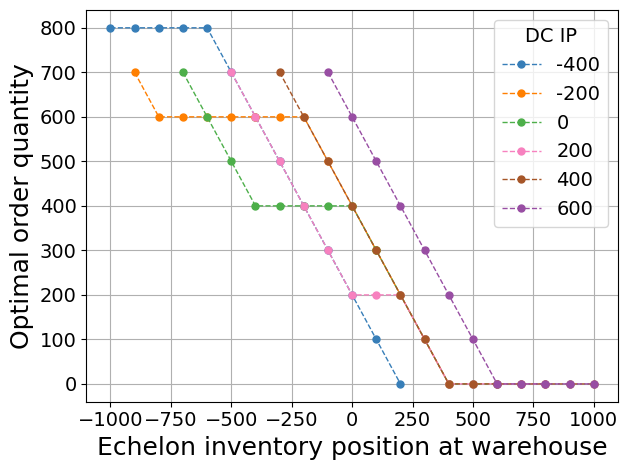

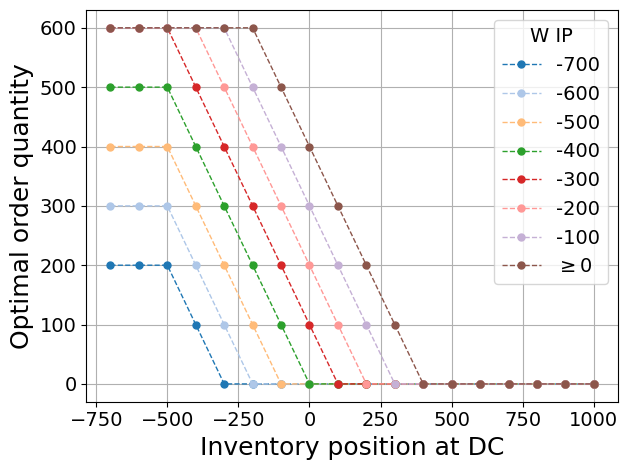

In [132]:
generate_partial_echelon_policy_plot(cL_optimal_policy, (-400, -200, 0, 200, 400, 600), lead_times, n_ech=2, colour_by="DC", x_lim = (-1000,1000), savefig=True)
generate_policy_plot(cL_optimal_policy, (-800, 0), lead_times, n_ech=2, colour_by="W", bbox_to_anchor=(1, 1), x_lim=(-1000, 1000), savefig="True")


In [20]:
def make_cost_plot_dict(optimal_dict, lead_times, n_ech):
    IPs = sorted(set(calculate_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_cost = dict((ip_dc, set()) for (ip_dc, ip_w) in IPs)
    DC_cost = dict((ip_w, set()) for (ip_dc, ip_w) in IPs)
    
    for state, cost in optimal_dict.items():
        ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)

        W_cost[ip_dc].add((ip_w, cost))
        DC_cost[ip_w].add((ip_dc, cost))

    return W_cost, DC_cost
    
def plot_cost(optimal_dict, lead_times, n_ech, colour_by="W", bbox_to_anchor=None):
    W_cost, DC_cost = make_cost_plot_dict(optimal_dict, lead_times, n_ech)

    cost_dict = DC_cost if colour_by == "W" else W_cost
    x_site = "DC" if colour_by == "W" else "warehouse"

    # Creates a cost vs IP plot where each line represents the cost given the IP at the other site
    cmap = plt.get_cmap("tab20")
    keys = sorted(cost_dict.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for ip, color in zip(keys, colors):
            sorted_pol = sorted(cost_dict[ip])
            ips, costs = zip(*sorted_pol)
            plt.plot(ips, costs, label=ip, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Initial inventory position at {x_site}", fontsize=18)
    plt.ylabel("Cost", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()

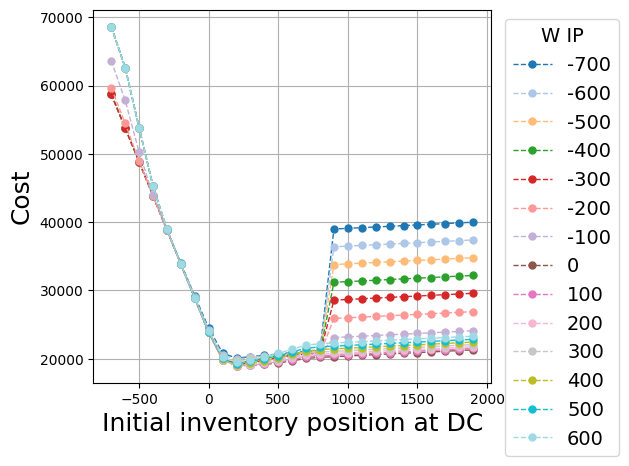

/tmp/ipykernel_740806/3308754547.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


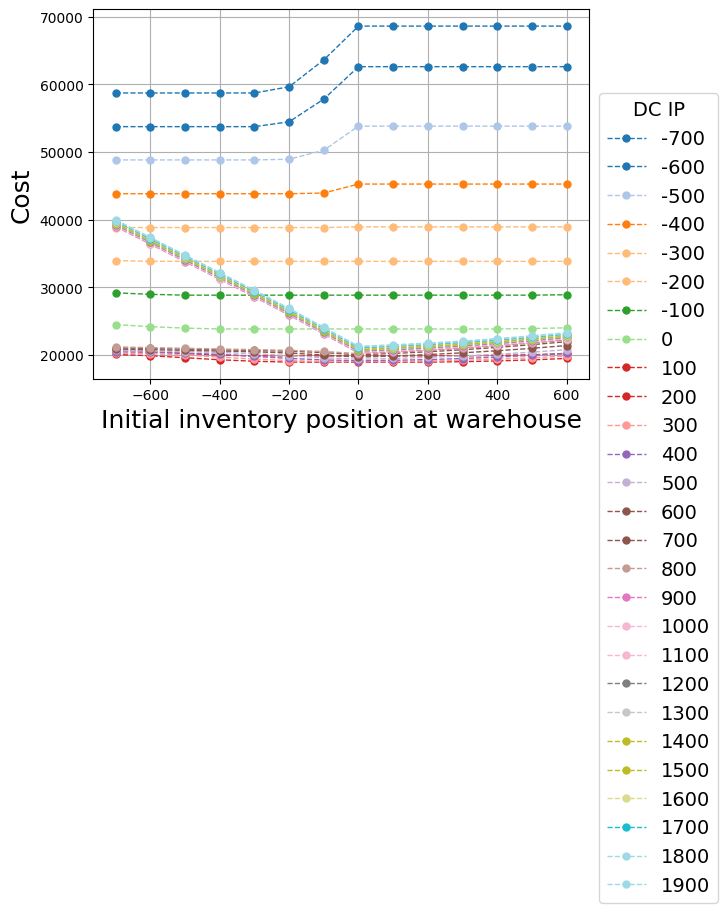

In [82]:
plot_cost(cL_cost_function, lead_times, 2, bbox_to_anchor=(1.01,1), colour_by = "W")
plot_cost(cL_cost_function, lead_times, 2, bbox_to_anchor=(1,0.8), colour_by="DC")

In [16]:
capacity = (-700, 600)
increment = 100
lead_times = [0, 0]
n_ech = 2
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
max_demand = max(demand_dist.keys())
hold_costs = [1, 0.5]
backlog_costs = [50, 25]

# Perform value iteration
gamma = 0.999
S, state_idx = create_state_space(capacity, increment, n_ech, max_demand, lead_times)
A, action_idx = create_action_space(capacity, increment, n_ech, max_demand)
P = create_P(S, A, state_idx, action_idx, demand_dist, capacity, n_ech, lead_times)
R = create_R(S, A, state_idx, action_idx, P, demand_dist, hold_costs, backlog_costs, capacity, n_ech, lead_times)
bellman_eq_cL = cL_value_update_func(S, A, state_idx, action_idx, P, capacity, demand_dist, n_ech, lead_times)
V_init = dict([(s, 0) for s in S])



In [17]:
c0_results = value_iteration(S, A, P, R, gamma, max_iterations = 100,
                                 bellman_eq=bellman_eq_cL, V_init = V_init, theta = 1e-7)
c0_optimal_policy = c0_results["optimal_policy"]
c0_cost_function = c0_results["value_function"]

10000.0
699.3
598.8005999999998
502.88831269560023
422.30654230442406
357.3120674507554
301.3535334611852
250.19997351666916
204.06557647209866
165.85355514555977
137.77401950480908
119.53315294303866
108.93779593021918
103.34133370693326
100.59915696921053
99.31924998726936
98.72504990255948
98.42965204572738
98.25667598256132
98.13131159271052
98.02367717233665
97.92242850692492
97.82344294346876
97.72527804720448
97.62744565199318
97.52978531185363
97.4322456193604
97.33481044243035
97.23747477870256
97.14023705924046
97.04309675298555
96.94605363691153
96.84910757794387
96.75225846891317
96.65550621005059
96.55885070373733
96.46229185300399
96.36582956114398
96.26946373158171
96.1731942678507
96.07702107358273
95.98094405250868
95.88496310845585
95.78907814534705
95.69328906720239
95.59759577813566
95.50199818235706
95.40649618417501
95.31108968799072
95.21577859830268
95.1205628197049
95.02544225688507
94.9304168146291
94.83548639781293
94.74065091141529
94.64591026050402
94.55126

In [19]:
c0_optimal_policy
store_results(c0_results, 2, f"c{lead_times[0]}-{lead_times[1]}", max(S)[0], max(A)[0], backlog_costs, hold_costs, gamma)

In [18]:
c0_results = pickle.load(open(fr'PolicyResults/2ech_c0-0_cap800_MOQ1200_sl98.0_gamma0.999.pkl', "rb"))
c0_policy = c0_results["optimal_policy"]
c0_costs = c0_results["value_function"]
c1_results = pickle.load(open(fr'PolicyResults/2ech_c1-1_cap600_MOQ1300_sl98.0_gamma0.999.pkl', "rb"))
c1_policy = c1_results["optimal_policy"]
c1_costs = c1_results["value_function"]
c0_policy
# pickle.load(open(fr'PolicyResults/2ech_c1-1_cap800_MOQ'))

{(-400, -400): (200, 600),
 (-400, -300): (300, 600),
 (-400, -200): (400, 600),
 (-400, -100): (500, 600),
 (-400, 0): (600, 600),
 (-400, 100): (600, 500),
 (-400, 200): (600, 400),
 (-400, 300): (600, 300),
 (-400, 400): (600, 200),
 (-400, 500): (600, 100),
 (-400, 600): (600, 0),
 (-400, 700): (600, 0),
 (-400, 800): (600, 0),
 (-300, -400): (100, 500),
 (-300, -300): (200, 500),
 (-300, -200): (300, 500),
 (-300, -100): (400, 500),
 (-300, 0): (500, 500),
 (-300, 100): (500, 400),
 (-300, 200): (500, 300),
 (-300, 300): (500, 200),
 (-300, 400): (500, 100),
 (-300, 500): (500, 0),
 (-300, 600): (500, 0),
 (-300, 700): (500, 0),
 (-300, 800): (500, 0),
 (-200, -400): (0, 400),
 (-200, -300): (100, 400),
 (-200, -200): (200, 400),
 (-200, -100): (300, 400),
 (-200, 0): (400, 400),
 (-200, 100): (400, 300),
 (-200, 200): (400, 200),
 (-200, 300): (400, 100),
 (-200, 400): (400, 0),
 (-200, 500): (400, 0),
 (-200, 600): (400, 0),
 (-200, 700): (400, 0),
 (-200, 800): (400, 0),
 (-100

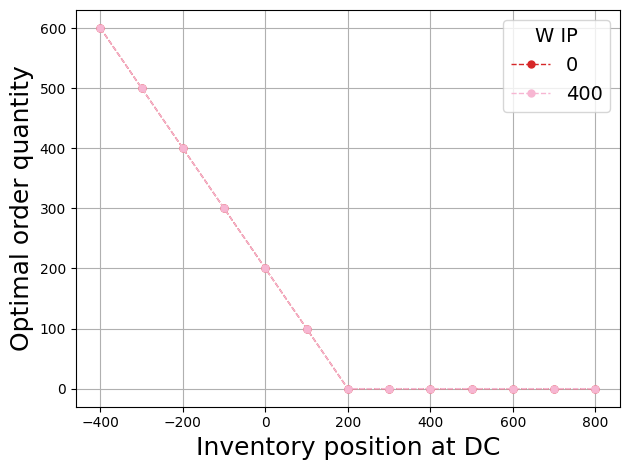

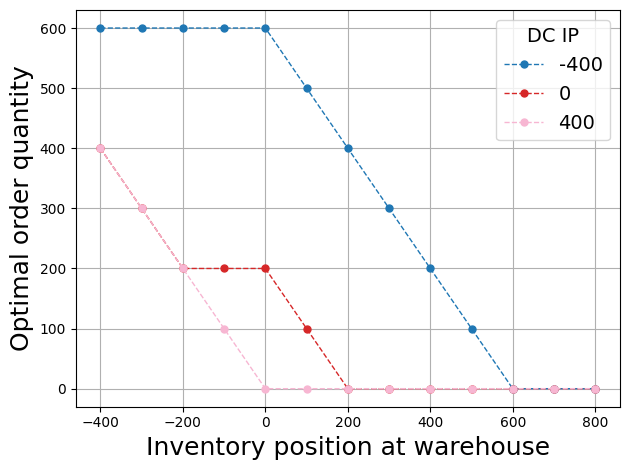

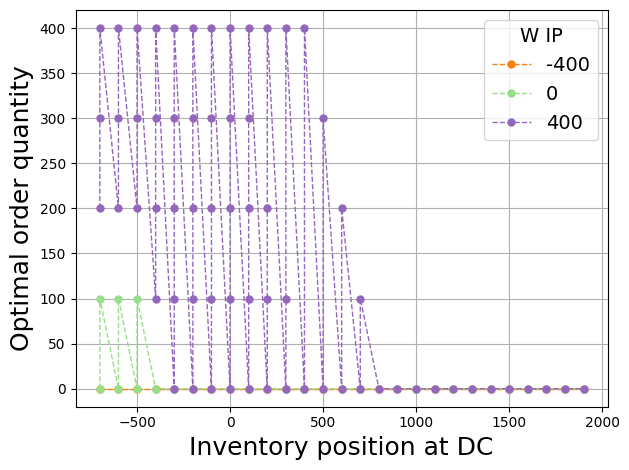

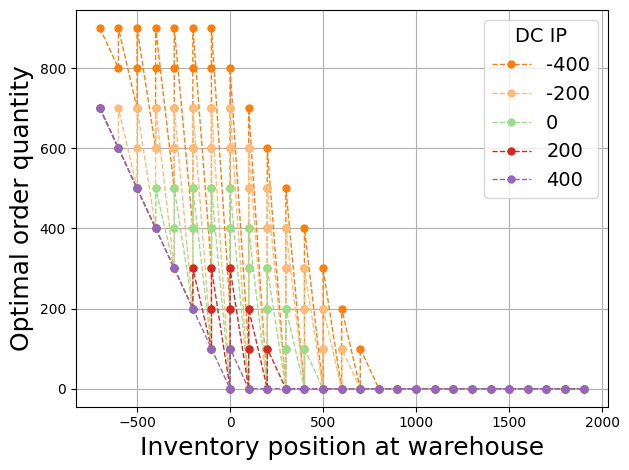

In [79]:
# generate_policy_plot(c0_policy, (800, 800), [0, 0], n_ech=2, colour_by="DC",  bbox_to_anchor=(0, 1))
# generate_policy_plot(c0_policy, (-400, 800), [0, 0], n_ech=2, colour_by="W", bbox_to_anchor=(1, 1))

# generate_echelon_policy_plot(c0_policy, (-500, 1300), lead_times, n_ech=2, colour_by="DC",  bbox_to_anchor=(1, 1))
# generate_partial_policy_plot(c0_policy, [ 0, 400], [0, 0], 2, colour_by= "W")
# generate_partial_policy_plot(c0_policy, [-400, 0, 400], [0, 0], 2, colour_by= "DC")

generate_partial_policy_plot(c1_policy, [-400, 0, 400], [1, 1], 2, colour_by= "W")
generate_partial_policy_plot(c1_policy, [-400, -200, 0, 200, 400], [1, 1], 2, colour_by= "DC")



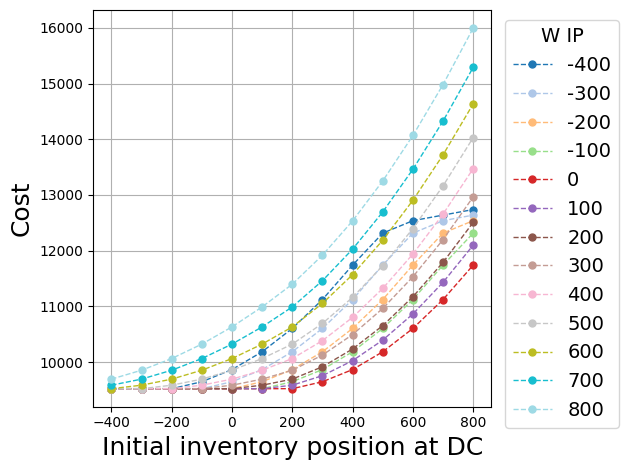

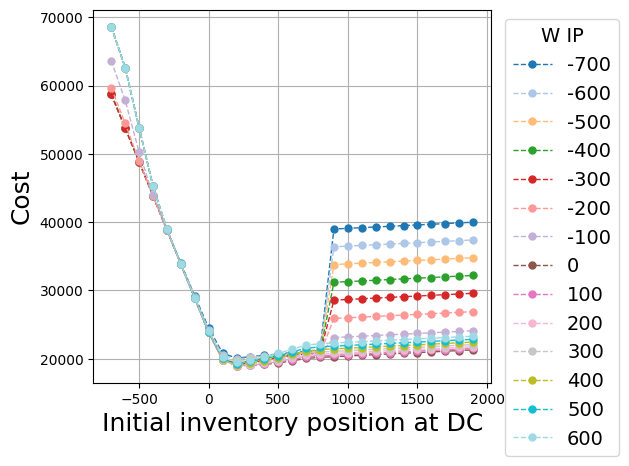

/tmp/ipykernel_740806/3308754547.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


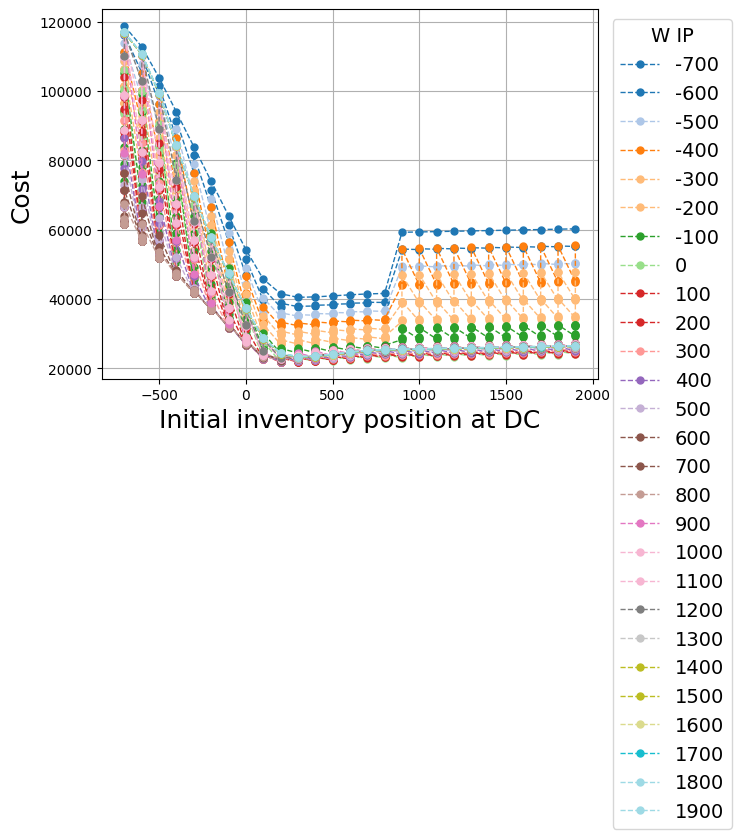

In [85]:
plot_cost(c0_costs, [0,0], 2, bbox_to_anchor=(1.01,1), colour_by = "W")
plot_cost(cL_cost_function, lead_times, 2, bbox_to_anchor=(1.01,1), colour_by = "W")
plot_cost(c1_costs, [1,1], 2, bbox_to_anchor=(1.01,1), colour_by = "W")